# Overview

The purpose of our final project is to analyze F1 data and determine what factors are important in determining a driver's success. In this first of two notebooks we will look at what factors are important and help classify whether or not a driver will finish on the podium, or top 3 in a race. F1 is very complex sport with lots going on to determine a team and driver's sucess. So, in this notebook we looked at a dataset of many previous races and their results. The dataset contained features like which lap was the driver's fastest lap, the time for the driver's fastest lap, the speed for the driver's fastest lap, and things like where the driver started their race, as well as the driver's championship ranking prior to the race.

To start our exploration we must first import the libraries needed for our analysis. This includes ggplot, GGally, and cluster.

In [49]:
if (!requireNamespace("ggplot2")) {
  install.packages("ggplot2")
}
library(ggplot2)

if (!requireNamespace("GGally")) {
  install.packages("GGally")
}
library(GGally)

if (!requireNamespace("cluster")) {
  install.packages("cluster")
}
library(cluster)

With the libaries imported we can now take our dataset in the form of a csv and put it into a dataset in R. Our dataset will be named results.

In [50]:
results <- read.csv("classification.csv")
str(results)

'data.frame':	26539 obs. of  18 variables:
 $ resultId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId         : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId  : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number         : chr  "22" "3" "7" "5" ...
 $ grid           : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position       : chr  "1" "2" "3" "4" ...
 $ positionText   : chr  "1" "2" "3" "4" ...
 $ positionOrder  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points         : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps           : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time           : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds   : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap     : chr  "39" "41" "41" "58" ...
 $ rank           : chr  "2" "3" "5" "7" ...
 $ fastestLapTime : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed: chr  "218.300" "217.586" "216.719" "215.464" ...
 $ statusId       : int 

The first step after the dataset is imported is to take a look at its structure. This allows us to see what we are working with in terms of data types, number of observations, number of variables, and more.

# Cleaning Data

At first glance it seems some of the variables we want to use are not in a form that we can work with. For example fastestLapTime is a character as well as fastestLapSpeed. Because of this, let's take a look at what some observations look like to get a good idea of how to fix them.

In [51]:
print(results$fastestLapTime)

    [1] "1:27.452" "1:27.739" "1:28.090" "1:28.603" "1:27.418" "1:29.639"
    [7] "1:29.534" "1:27.903" "1:28.753" "1:29.558" "1:30.892" "1:31.384"
   [13] "1:28.175" "1:29.502" "1:29.310" "1:32.021" "\\N"      "\\N"     
   [19] "\\N"      "\\N"      "\\N"      "1:28.736" "1:35.405" "1:35.921"
   [25] "1:35.922" "1:36.068" "1:35.462" "1:35.366" "1:36.696" "1:36.288"
   [31] "1:36.206" "1:35.715" "1:36.956" "1:36.962" "1:36.693" "1:36.782"
   [37] "1:38.171" "1:38.504" "1:37.711" "1:36.870" "1:35.914" "1:40.330"
   [43] "\\N"      "\\N"      "1:33.600" "1:33.709" "1:33.775" "1:33.565"
   [49] "1:33.193" "1:34.204" "1:34.305" "1:34.072" "1:34.807" "1:35.194"
   [55] "1:34.855" "1:35.057" "1:35.520" "1:35.433" "1:35.333" "1:35.324"
   [61] "1:35.891" "1:35.351" "1:35.442" "1:35.129" "1:36.125" "\\N"     
   [67] "1:21.670" "1:21.801" "1:22.017" "1:22.106" "1:22.564" "1:22.353"
   [73] "1:23.549" "1:22.758" "1:22.519" "1:23.439" "1:23.007" "1:22.842"
   [79] "1:24.617" "1:23.319" "1:22.68

In [52]:
print(results$fastestLapSpeed)

    [1] "218.300" "217.586" "216.719" "215.464" "218.385" "212.974" "213.224"
    [8] "217.180" "215.100" "213.166" "210.038" "208.907" "216.510" "213.300"
   [15] "213.758" "207.461" "\\N"     "\\N"     "\\N"     "\\N"     "\\N"    
   [22] "215.141" "209.158" "208.033" "208.031" "207.715" "209.033" "209.244"
   [29] "206.366" "207.240" "207.417" "208.481" "205.812" "205.800" "206.372"
   [36] "206.182" "203.265" "202.578" "204.222" "205.995" "208.048" "198.891"
   [43] "\\N"     "\\N"     "208.153" "207.911" "207.765" "208.231" "209.062"
   [50] "206.819" "206.597" "207.109" "205.503" "204.668" "205.399" "204.963"
   [57] "203.969" "204.155" "204.369" "204.389" "203.180" "204.331" "204.136"
   [64] "204.808" "202.686" "\\N"     "205.191" "204.863" "204.323" "204.102"
   [71] "202.969" "203.489" "200.576" "202.494" "203.080" "200.841" "201.886"
   [78] "202.288" "198.045" "201.130" "202.677" "199.837" "203.243" "192.922"
   [85] "194.862" "196.128" "\\N"     "\\N"     "221.734" "222.0

By quickly scrolling through we can see that there missing values of \\N in both the fastestLapTime and fastestLapSpeed. Additionally, by looking at the dataset you can notice that fastestLap and rank sometimes have missing values. Because of this, to clean our data, we'll get rid of all observations that are missing values.

In [53]:
results <- results[!results$fastestLap == "\\N",]
results <- results[!results$rank == "\\N",]
results <- results[!results$fastestLapTime == "\\N",]
results <- results[!results$fastestLapSpeed == "\\N",]
str(results)


'data.frame':	8040 obs. of  18 variables:
 $ resultId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId         : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId  : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number         : chr  "22" "3" "7" "5" ...
 $ grid           : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position       : chr  "1" "2" "3" "4" ...
 $ positionText   : chr  "1" "2" "3" "4" ...
 $ positionOrder  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points         : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps           : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time           : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds   : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap     : chr  "39" "41" "41" "58" ...
 $ rank           : chr  "2" "3" "5" "7" ...
 $ fastestLapTime : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed: chr  "218.300" "217.586" "216.719" "215.464" ...
 $ statusId       : int  

After removing all missing values we are left with 8040 observations. Let's take a look at the summary of our dataset now.

In [54]:
summary(results)

    resultId         raceId          driverId     constructorId   
 Min.   :    1   Min.   :   1.0   Min.   :  1.0   Min.   :  1.00  
 1st Qu.: 7798   1st Qu.: 103.0   1st Qu.: 14.0   1st Qu.:  4.00  
 Median :22314   Median : 908.0   Median : 67.0   Median :  9.00  
 Mean   :17841   Mean   : 705.6   Mean   :395.5   Mean   : 53.54  
 3rd Qu.:24430   3rd Qu.:1021.0   3rd Qu.:826.0   3rd Qu.:117.00  
 Max.   :26544   Max.   :1133.0   Max.   :860.0   Max.   :215.00  
    number               grid         position         positionText      
 Length:8040        Min.   : 0.00   Length:8040        Length:8040       
 Class :character   1st Qu.: 5.75   Class :character   Class :character  
 Mode  :character   Median :11.00   Mode  :character   Mode  :character  
                    Mean   :10.85                                        
                    3rd Qu.:16.00                                        
                    Max.   :24.00                                        
 positionOrde

Our data looks pretty good so far, but after looking at it further one of the variables, grid, has a minimum of 0. This is could mean a lot of things, whether its an error, the driver got penalized, or didn't race cause of other factors. So, it would be best to get rid of the 0 values in grid.

In [55]:
results <- results[!results$grid == 0,]
str(results)


'data.frame':	7977 obs. of  18 variables:
 $ resultId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId         : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId  : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number         : chr  "22" "3" "7" "5" ...
 $ grid           : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position       : chr  "1" "2" "3" "4" ...
 $ positionText   : chr  "1" "2" "3" "4" ...
 $ positionOrder  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points         : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps           : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time           : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds   : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap     : chr  "39" "41" "41" "58" ...
 $ rank           : chr  "2" "3" "5" "7" ...
 $ fastestLapTime : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed: chr  "218.300" "217.586" "216.719" "215.464" ...
 $ statusId       : int  

After removing the 0 values in grid and looking at the structure once again, we are left with 7977 observations. Now we can start cleaning up the variables to move forward with our analysis.

To start we'll convert the variables that are simple and easy. That includes fastestLap, rank, and fastestLapSpeed.

In [56]:
results$fastestLap <- as.numeric(results$fastestLap)
results$rank <- as.numeric(results$rank)
results$fastestLapSpeed <- as.numeric(results$fastestLapSpeed)
str(results)


'data.frame':	7977 obs. of  18 variables:
 $ resultId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId         : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId  : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number         : chr  "22" "3" "7" "5" ...
 $ grid           : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position       : chr  "1" "2" "3" "4" ...
 $ positionText   : chr  "1" "2" "3" "4" ...
 $ positionOrder  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points         : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps           : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time           : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds   : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap     : num  39 41 41 58 43 50 54 20 15 23 ...
 $ rank           : num  2 3 5 7 1 14 8 4 9 13 ...
 $ fastestLapTime : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed: num  218 218 217 215 218 ...
 $ statusId       : int  1 1 

Looking at the structure shows us that we were successful in converting those variables to numeric data types.

It's now time to handle the fastestLapTime column which needs to not only be converted to a numeric data type but to a single number. To do this we'll convert the lap time to milliseconds.

In [57]:
time_to_milliseconds <- function(time_str) {
  parts <- strsplit(time_str, ":")[[1]]
  minutes <- as.numeric(parts[1])
  seconds_milliseconds <- strsplit(parts[2], "\\.")[[1]]
  seconds <- as.numeric(seconds_milliseconds[1])
  milliseconds <- as.numeric(seconds_milliseconds[2])

  total_milliseconds <- (minutes * 60 * 1000) + (seconds * 1000) + milliseconds
  return(total_milliseconds)
}

results$fastestLapTime_MS <- sapply(results$fastestLapTime, time_to_milliseconds)

str(results)

'data.frame':	7977 obs. of  19 variables:
 $ resultId         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId           : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId    : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number           : chr  "22" "3" "7" "5" ...
 $ grid             : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position         : chr  "1" "2" "3" "4" ...
 $ positionText     : chr  "1" "2" "3" "4" ...
 $ positionOrder    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points           : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps             : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time             : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds     : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap       : num  39 41 41 58 43 50 54 20 15 23 ...
 $ rank             : num  2 3 5 7 1 14 8 4 9 13 ...
 $ fastestLapTime   : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed  : num  218 218 217 215 218

As we can see we now have a new column titled fastestLapTime_MS that has all fastest laps in the form of milliseconds.

With our columns almost ready for analysis we now need to add another column that we will be using for classification. This column is titled podium, and will be a factor with two values, "Y" for yes the driver finished on the podium, and "N" for no the driver did not finish on the podium.

In [58]:
results$podium <- ifelse(results$positionOrder <= 3, "Y", "N")

results$podium <- as.factor(results$podium)

str(results)

'data.frame':	7977 obs. of  20 variables:
 $ resultId         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ raceId           : int  18 18 18 18 18 18 18 18 18 18 ...
 $ driverId         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ constructorId    : int  1 2 3 4 1 3 5 6 2 7 ...
 $ number           : chr  "22" "3" "7" "5" ...
 $ grid             : int  1 5 7 11 3 13 17 15 2 18 ...
 $ position         : chr  "1" "2" "3" "4" ...
 $ positionText     : chr  "1" "2" "3" "4" ...
 $ positionOrder    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ points           : num  10 8 6 5 4 3 2 1 0 0 ...
 $ laps             : int  58 58 58 58 58 57 55 53 47 43 ...
 $ time             : chr  "1:34:50.616" "+5.478" "+8.163" "+17.181" ...
 $ milliseconds     : chr  "5690616" "5696094" "5698779" "5707797" ...
 $ fastestLap       : num  39 41 41 58 43 50 54 20 15 23 ...
 $ rank             : num  2 3 5 7 1 14 8 4 9 13 ...
 $ fastestLapTime   : chr  "1:27.452" "1:27.739" "1:28.090" "1:28.603" ...
 $ fastestLapSpeed  : num  218 218 217 215 218

Now our column is added and all drivers who finished top 3 in their races have a Y as their podium value and all drivers who finished outside the top 3 have a N as their podium value.

It is now time to trim down our dataset. Our goal is to leave columns that may have a good chance of helping us classify whether or not a driver will finish on the podium. We need to remove many columns for different reasons. For example, driverId and constructorId need to be removed because their values are not continuous but rather just assigned to a person or team. Variables like positionOrder, points, and time, need to be removed to prevent data leakage. In other words, our model cannot use them because they give it information that is not available until after the race, which would make our podium classification pointless.

In [59]:
results <- results[, !(names(results) %in% c("positionOrder", "fastestLapTime", "driverId", "constructorId",
"resultId", "raceId", "number", "position", "positionText",
"points", "laps", "time", "milliseconds", "statusId"))]
str(results)

'data.frame':	7977 obs. of  6 variables:
 $ grid             : int  1 5 7 11 3 13 17 15 2 18 ...
 $ fastestLap       : num  39 41 41 58 43 50 54 20 15 23 ...
 $ rank             : num  2 3 5 7 1 14 8 4 9 13 ...
 $ fastestLapSpeed  : num  218 218 217 215 218 ...
 $ fastestLapTime_MS: num  87452 87739 88090 88603 87418 ...
 $ podium           : Factor w/ 2 levels "N","Y": 2 2 2 1 1 1 1 1 1 1 ...


After removing the columns that would negatively affect our classisfication we are left with 6 variables. Grid, which is the position the driver starts the race in. FastestLap, which is the lap number where the driver has their fastest lap of the race. Rank, which is where the driver is in the championship standings before the race. FastestLapSpeed, which is the speed at which the driver was going during their fastest lap. FastestLapTime_MS, which is how long each drivers fastest lap was in milliseconds. And finally, podium, which is whether or not the driver finished on the podium. This will be our target variable.

Now we can take a look at the summary of our new cleaned dataset.

In [60]:
summary(results)

      grid         fastestLap         rank       fastestLapSpeed 
 Min.   : 1.00   Min.   : 1.00   Min.   : 1.00   Min.   : 89.54  
 1st Qu.: 6.00   1st Qu.:33.00   1st Qu.: 6.00   1st Qu.:193.26  
 Median :11.00   Median :46.00   Median :11.00   Median :204.88  
 Mean   :10.94   Mean   :42.62   Mean   :10.66   Mean   :203.87  
 3rd Qu.:16.00   3rd Qu.:54.00   3rd Qu.:16.00   3rd Qu.:217.05  
 Max.   :24.00   Max.   :85.00   Max.   :24.00   Max.   :257.32  
 fastestLapTime_MS podium  
 Min.   : 55404    N:6780  
 1st Qu.: 80775    Y:1197  
 Median : 90309            
 Mean   : 90832            
 3rd Qu.: 99527            
 Max.   :202300            

The summary reveals that all of our remaining variables are ready for analysis. Additionally, the summary shows the wide variety of some of our columns such as fastestLap, fastestLapSpeed, and fastestLapTime_MS. We can also see that in our podium column there are way more Ns than Ys. This is because only 3 drivers each race are on the podium while the vast majority are not.

# Visualizations

With the data ready we can now start looking at visualizations of our data and features. To begin, we'll take a look at histograms of our predicting features color-coded by whether or not the driver was on the podium. This will give us a good look at what features potentially separate a podium finish from a non podium finish

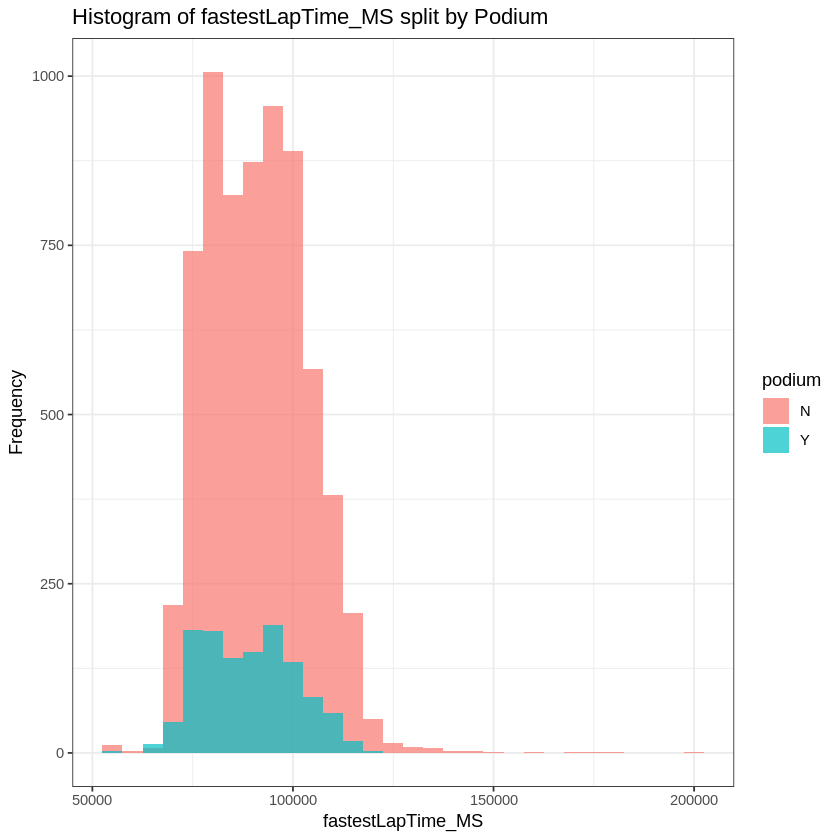

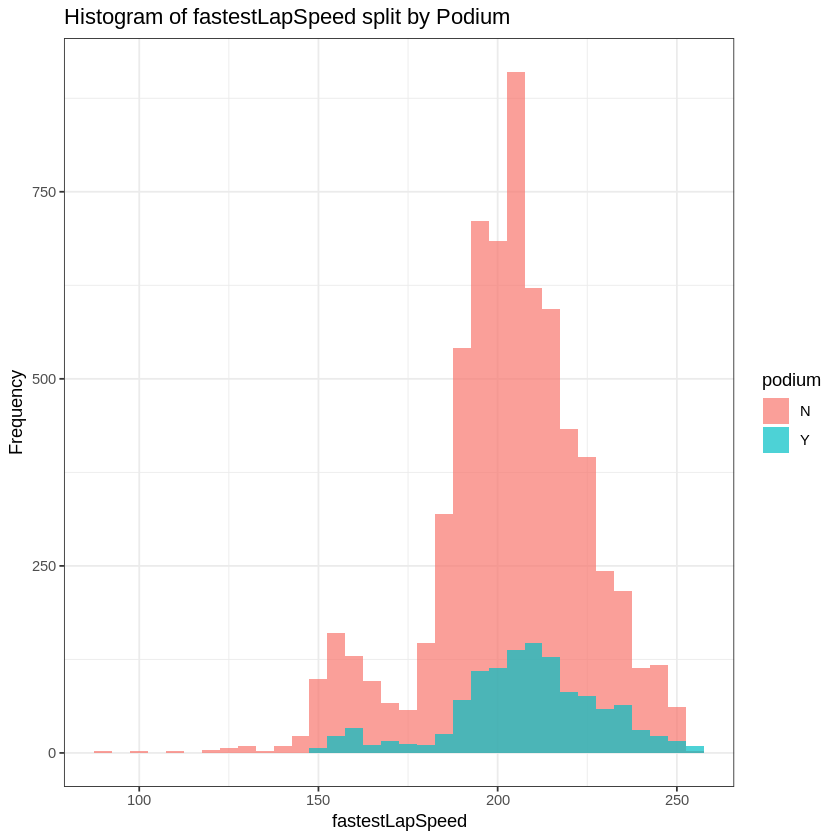

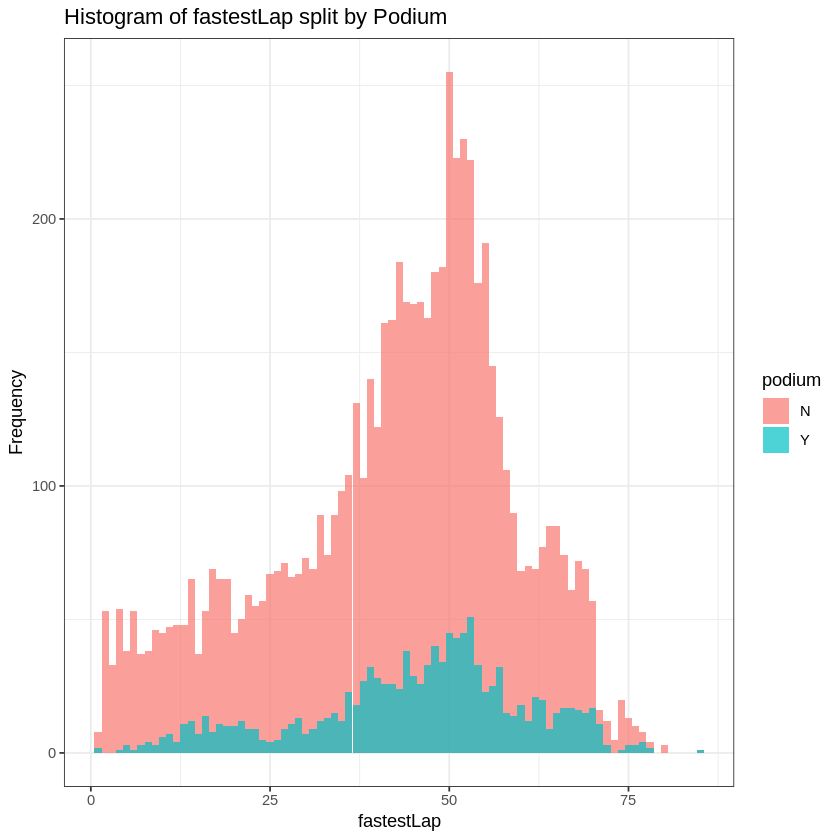

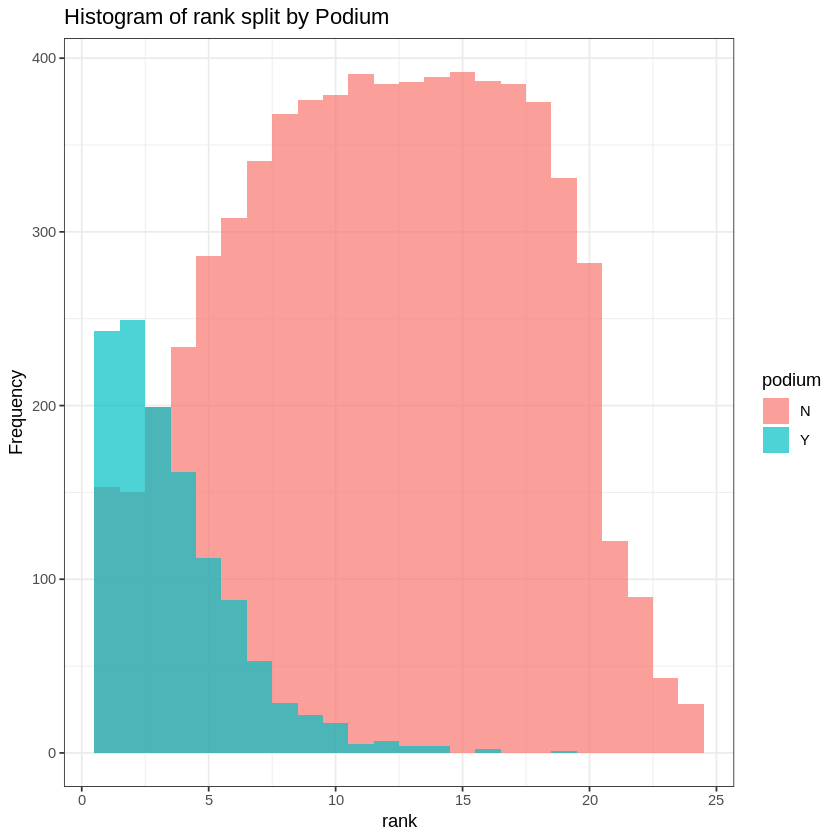

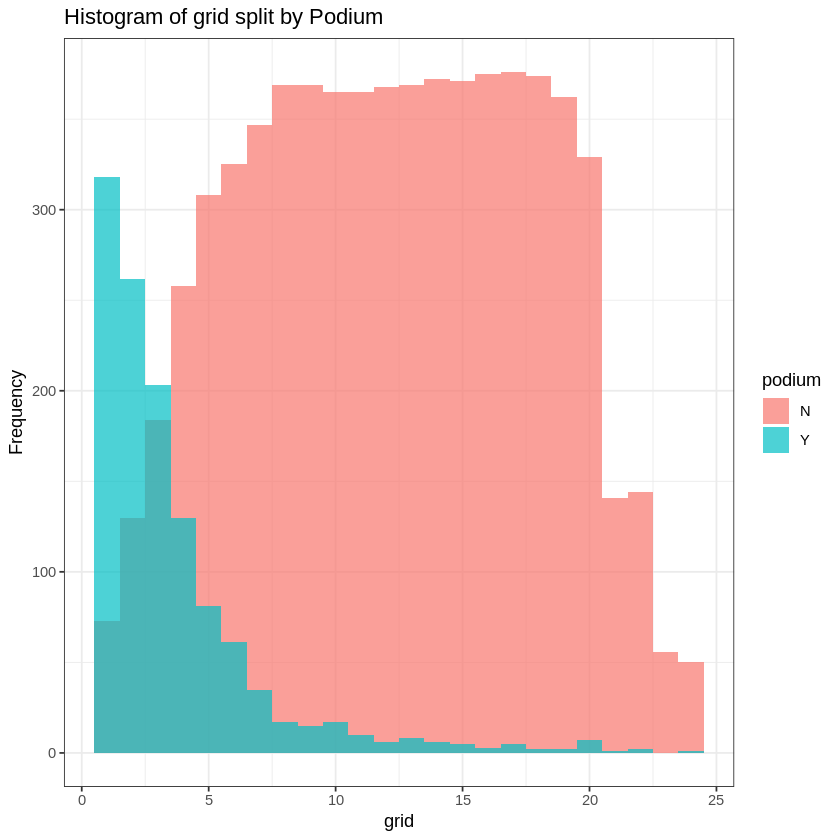

In [61]:
variables_to_plot <- c("fastestLapTime_MS", "fastestLapSpeed", "fastestLap", "rank", "grid")

for (var in variables_to_plot) {
  p <- ggplot(results, aes_string(x = var, fill = "podium")) +
    geom_histogram(binwidth = ifelse(var == "fastestLapTime_MS", 5000,
                                   ifelse(var == "fastestLapSpeed", 5,
                                          ifelse(var == "fastestLap", 1, 1))),
                   alpha = 0.7, position = "identity") +
    labs(title = paste("Histogram of", var, "split by Podium"),
         x = var, y = "Frequency") +
    theme_bw()
  print(p)
}

The first histogram revealed the distribution of the fastestLapTime_MS variable. The feature is somewhat normally distributed with a slight skew to the right and a mean around 90000 milliseconds. As for the split between Y and N podium, there isn't much. They overlap completely and have the same shape meaning the time of the drivers fastest lap probably isn't the best predictor of a podium finish. This makes sense because races have many laps in them, sometimes as high as 70. So, one quick lap isn't going to change the drivers position very much.

The second histogram shows the distribution for fastestLapSpeed. This variable is similar to fastestLapTime_MS and has a slightly normal distribution with a small skew to the left. The mean for this feature is around 200 kph. Once again the Y podium observations and N podium observations overlap meaning this feature also is not great for predicting a podium finish. This too makes sense, because each year every team makes improvements to their car within regulations. Therefore it makes sense most cars are very similar in the speed they can acheive. This means we are still looking for something else that differentiates a podium driver for the rest.

The next histogram highlights the distribution for the drivers fastest laps. This shape is similar to the others but is more skewed left. The mean for this feature is around the 40th lap. The makes sense because it takes time for drivers to get entirely comfortable and in the zone during a race. Additionally, depending on the tire type, around 30 to 40 laps into the race is when drivers start going into the pits for new tires. Just like the last two variables, the Y and N podium observations follow very similar shapes with a lot of overlap. Once again revealing this feature may not be the best for classification.

The fourth histogram shows rank's distribution. This shape is different from the last three histograms as the Y and N observations now have two different shapes. N observations show us a standard normal distribtion while the Y observations have a skewed right shape. There is some overlap between the two but now the visualizations are showing us potential predictors for a podium. Most of the Y observations have low ranks, meaning the drivers were leading the championships rankings before the race. Because of this rank needs to be noted as a potential predictor of podium finishes.

The final histogram reveals the grid feature's distribution. The grid feature is the position where the driver started the race from. Obviously starting from the front is very advantageous which is why this histogram is very similar to rank's histogram. The N observations show a normal distribution while the Y observations create a skewed right shape. Just like rank, grid position must be highlighted as another potential great predictor of a podium finish.

After looking at all 5 of our features and their distributions it became clear that rank and grid were to great predictors. Because of this, we wanted to create a scatterplot of rank and grid color coded by the podium feature to see where most of the winners landed in terms of starting position and championship rankings.

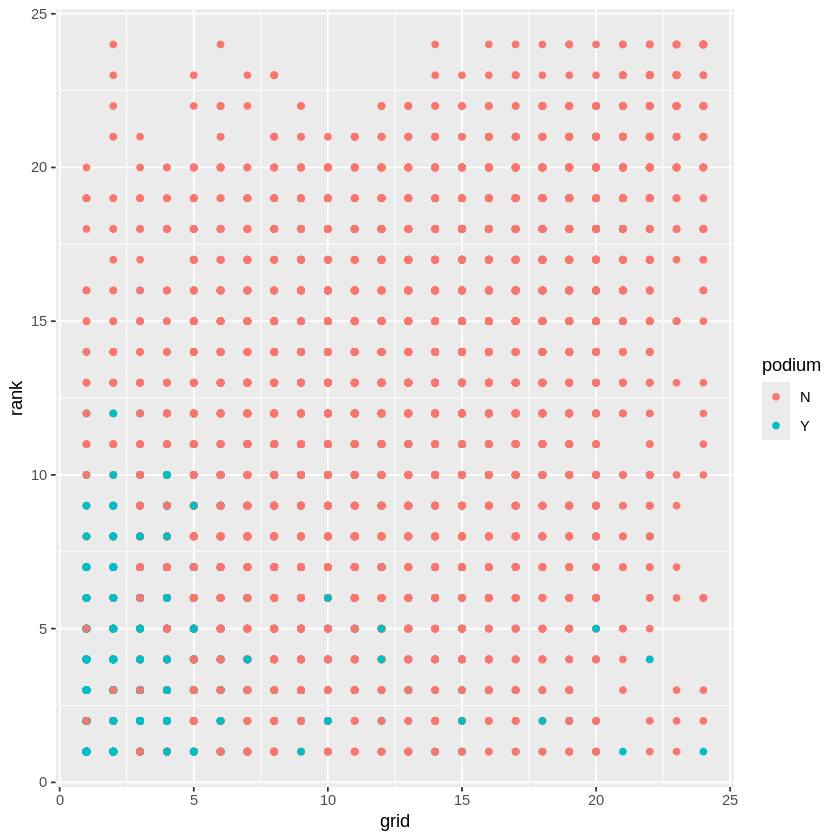

In [62]:
ggplot(results, aes(x = grid, y = rank, color = podium)) +
  geom_point()

By looking at this scatterplot it's obvious almost all of the winners fall in the high ranking, good starting position group. However, it is important to note that rank has a little more variety in winners than grid does. In other words, there are more winners from higher numbered rankings than there are winners from further back starting positions. This furthers our understanding of just how important grid position is.

# Clustering by K-Means

In an attempt to potentially create more features that we can use for prediction, we can turn towards clustering to try and make clusters that may predict a podium finish. To do this, we first need to normalize our dataset.

In [63]:
library(dplyr)

normalized_results <- results %>%
  mutate(
    grid_norm = scale(grid),
    fastestLap_norm = scale(fastestLap),
    rank_norm = scale(rank),
    fastestLapSpeed_norm = scale(fastestLapSpeed),
    fastestLapTime_MS_norm = scale(fastestLapTime_MS)
  ) %>%
  select(grid_norm, fastestLap_norm, rank_norm, fastestLapSpeed_norm, fastestLapTime_MS_norm)

summary(normalized_results)

         grid_norm.V1              fastestLap_norm.V1     
 Min.   :-1.61614533565e+00   Min.   :-2.49758450671e+00  
 1st Qu.:-8.03191069564e-01   1st Qu.:-5.77284594297e-01  
 Median : 9.76319652644e-03   Median : 2.02837245120e-01  
 Mean   :-1.00000000000e-16   Mean   :-1.00000000000e-16  
 3rd Qu.: 8.22717462617e-01   3rd Qu.: 6.82912223223e-01  
 Max.   : 2.12344428836e+00   Max.   : 2.54320276337e+00  
         rank_norm.V1          fastestLapSpeed_norm.V1  
 Min.   :-1.61872099296e+00   Min.   :-5.3564668172700  
 1st Qu.:-7.80451386706e-01   1st Qu.:-0.4970154841950  
 Median : 5.78182195516e-02   Median : 0.0471868458611  
 Mean   :-1.00000000000e-16   Mean   : 0.0000000000000  
 3rd Qu.: 8.96087825809e-01   3rd Qu.: 0.6174842773150  
 Max.   : 2.23731919582e+00   Max.   : 2.5039211765900  
 fastestLapTime_MS_norm.V1 
 Min.   :-2.8626527156000  
 1st Qu.:-0.8126383927190  
 Median :-0.0422770922434  
 Mean   : 0.0000000000000  
 3rd Qu.: 0.7025509408790  
 Max.   : 9.00676133

With the dataset and its features normalized its time for clustering. We will use kmeans to compute clustering measures and calculate the silhouette width to find the best k. Additionally we will plot the different silhouette width's to give a visualization for our kmean clustering. We will use a seed of 19.

The best k: 2 


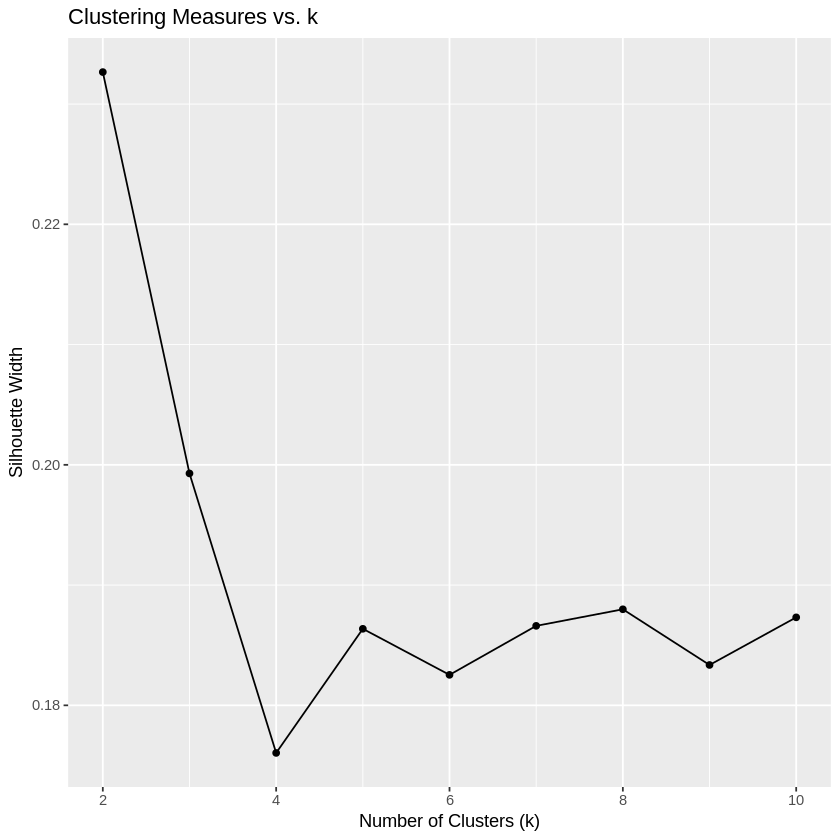

In [64]:
set.seed(19)

compute_clustering_measures <- function(k, data) {
  kmeans_model <- kmeans(data, centers = k, iter.max = 100)

  sil <- silhouette(kmeans_model$cluster, dist(data))
  mean_sil <- mean(sil[, 3])

  return(mean_sil)
}


k_values <- 2:10
clustering_measures <- numeric(length(k_values))


for (i in seq_along(k_values)) {
  clustering_measures[i] <- compute_clustering_measures(k_values[i], normalized_results)
}

plot_data <- data.frame(k = k_values, measure = clustering_measures)


ggplot(plot_data, aes(x = k, y = measure)) +
  geom_line() +
  geom_point() +
  labs(x = "Number of Clusters (k)", y = "Silhouette Width", title = "Clustering Measures vs. k")

best_k <- k_values[which.max(clustering_measures)]
cat("The best k:", best_k, "\n")

By looking at the graph and calculating different width's we can see that the best k is 2, meaning we will have 2 clusters.

Using this k, we can train a model and look at the distribution of our two new clusters

In [65]:
k <- best_k
kmeans_model <- kmeans(normalized_results, centers = k)
table(kmeans_model$cluster)


   1    2 
3787 4190 

Examining the distribution reveals to us that cluster 1 has 3787 observations while cluster 2 has 4190.

Now, in order to check if we can use our clusters as features to predict a podium finsih we will look at 5 different histograms all split by cluster, one for each feature and see if there is any overlap. With a lot of overlap, the cluster might not be the best idea for trying to predict our target feature.

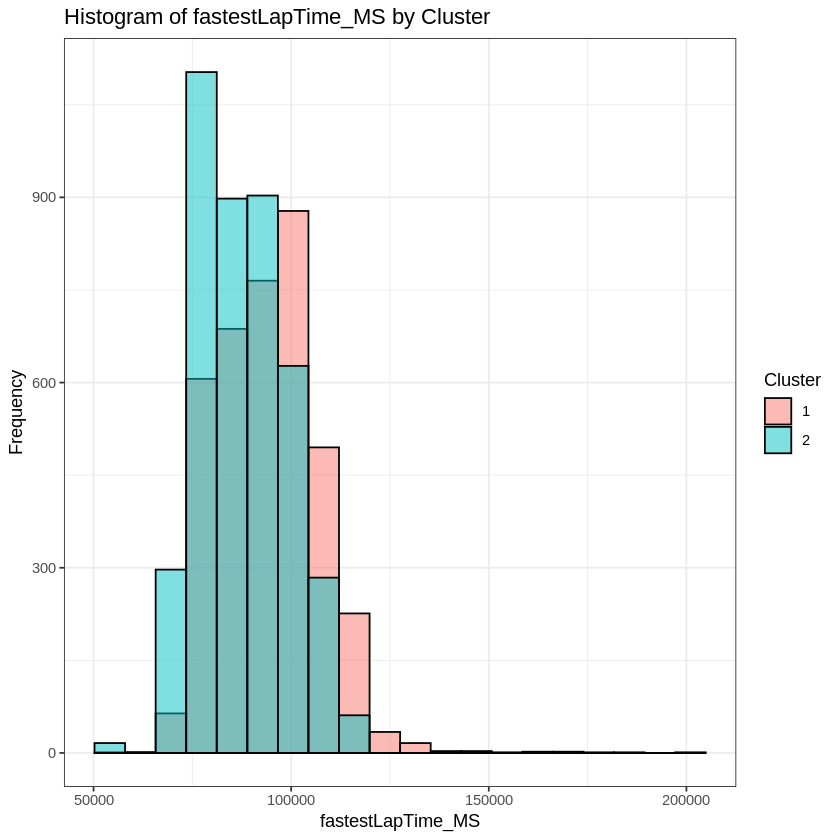

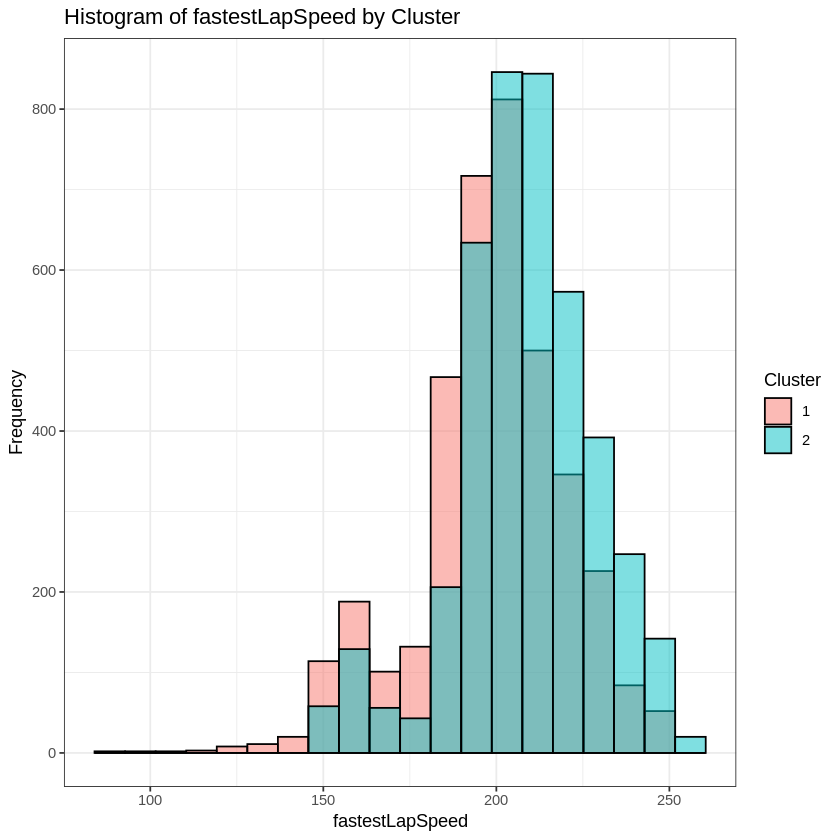

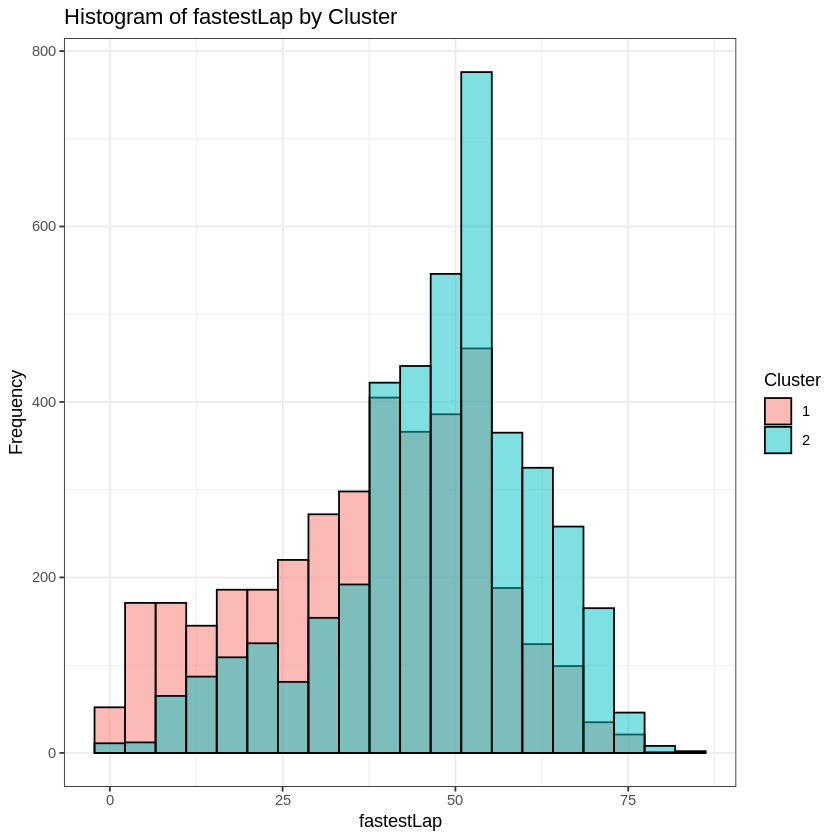

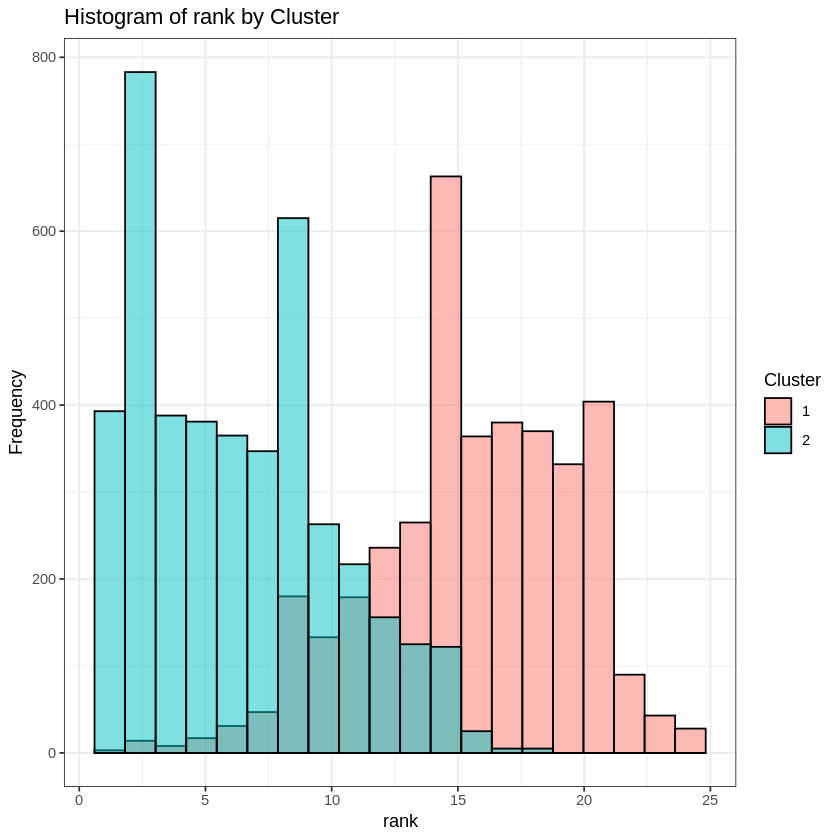

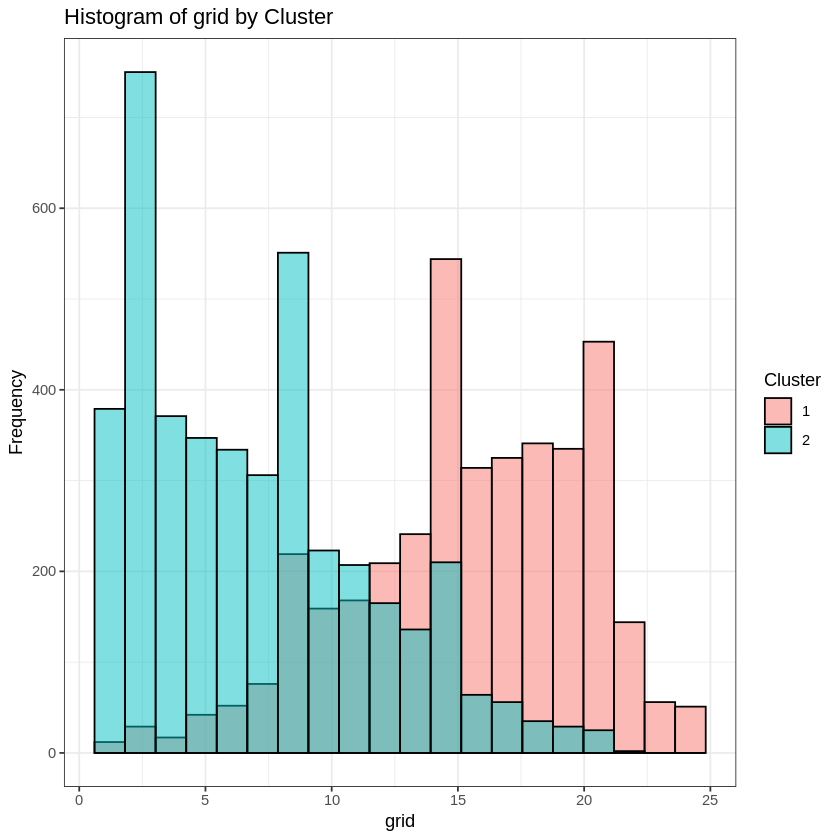

In [66]:
results$cluster <- kmeans_model$cluster

features <- c("fastestLapTime_MS", "fastestLapSpeed", "fastestLap", "rank", "grid")

for (feature in features) {
  print(ggplot(results, aes_string(x = feature, fill = "factor(cluster)")) +
          geom_histogram(bins = 20, alpha = 0.5, position = "identity", color = "black") +
          labs(title = paste("Histogram of", feature, "by Cluster"),
               x = feature,
               y = "Frequency",
               fill = "Cluster") +
          theme_bw())
}

Looking at the histogram reveals a lot of overlap between both clusters, especially for fastestLapTime_MS, fastestLapSpeed, and fastestLap. Rank and grid have less overlap but still too much to consider our cluster good features for prediction.

With our biggest predicting features established as grid and rank it is time to now train our model and create a decision tree.

# Splitting Into Training and Testing Datasets

First we will use a seed of 19 and will split the data 80% for training and 20% for testing.

In [67]:
set.seed(19)
train_indices <- sample(1:nrow(results), 0.8 * nrow(results))
train_data <- results[train_indices, ]
test_data <- results[-train_indices, ]

With the data split, we need a way to look at and analyze the distribution of Y and N observations. Therefore, we created a function that takes a dataset and a feature and shows the distribution of the given feature.

In [68]:
display_categorical_table <- function(df, dataset_name, feature_name) {
  if (!(feature_name %in% colnames(df))) {
    stop("Feature name not found in the data frame.")
  }

  if (!is.factor(df[[feature_name]])) {
    warning("The feature is not a factor. Converting it to a factor for analysis.")
    df[[feature_name]] <- as.factor(df[[feature_name]])
  }

  counts <- table(df[[feature_name]])
  percentages <- round(prop.table(counts) * 100, 2)

  cat("Table of", feature_name, "in ", dataset_name, ":\n")

  df_table <- data.frame(
    Category = names(counts),
    Count = as.vector(counts),
    Percentage = as.vector(percentages)
  )

  print(df_table)
}

This code will display a categorical table that we use to make sure the distributions for all datasets look correct.

In [69]:
display_categorical_table(results, 'results dataset', 'podium')

Table of podium in  results dataset :
  Category Count Percentage
1        N  6780      84.99
2        Y  1197      15.01


After running the function for the original dataset we can once again see that there are many more N observations with about 85% of the observations being N while the other approximately 15% is Y observations.

We can now run the same function using the training dataset this time.

In [70]:
display_categorical_table(train_data, 'results dataset', 'podium')

Table of podium in  results dataset :
  Category Count Percentage
1        N  5412      84.81
2        Y   969      15.19


After it was ran we can see a very similar distribution. This time, the Y observations have a slightly higher pectange at 15.19% instead of 15.01%.

Finally, we can run the function for the testing data set.

In [71]:
display_categorical_table(test_data, 'results dataset', 'podium')

Table of podium in  results dataset :
  Category Count Percentage
1        N  1368      85.71
2        Y   228      14.29


In the testing data there are slightly less Y observations for a percentage of 14.29%.

Looking at all 3 distributions we can see that the distribution for the podium features are relatively similar every time with N observations making up around 85% of the data and Y observations filling in the remaining 15%

# Decision Tree and Confusion Matrix

Now that we have a good idea of the distributions we can make our decision tree and model. We can load in a new library "rpart" to display the decision tree.

In [72]:
if(!require(rpart)){install.packages("rpart")}
if(!require(rpart.plot)){install.packages("rpart.plot")}
library(rpart)
library(rpart.plot)

if(!require(caret)){install.packages("caret")}
library(caret)

Using the newly imported rpart we can train a tree model with the training data to classify whether or not a driver finished on the podium.

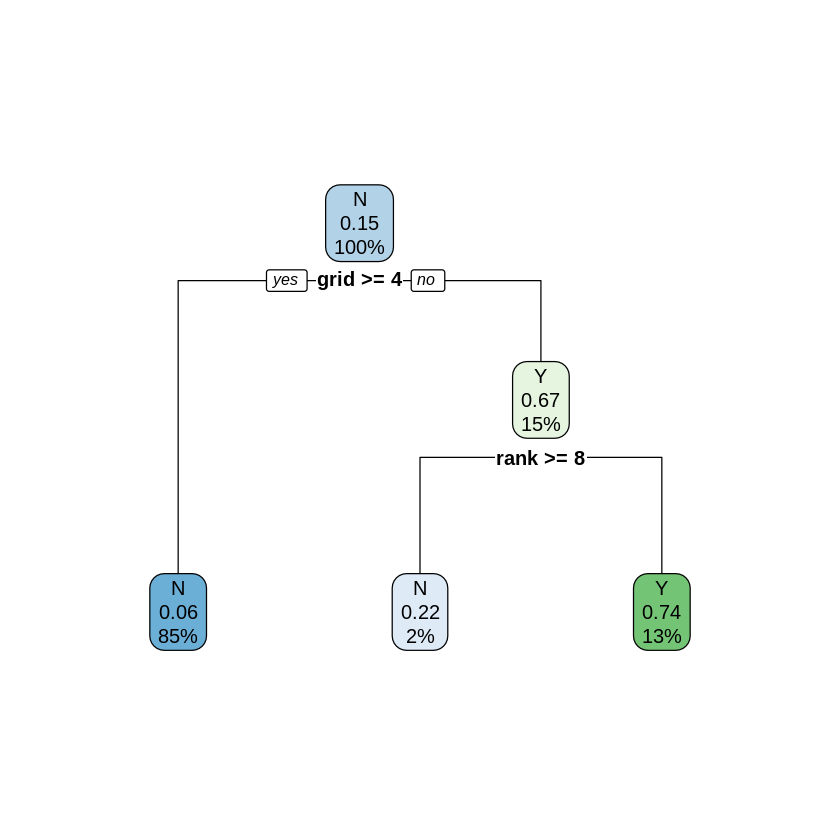

In [73]:
tree_model <- rpart(podium ~ ., data = train_data, method = "class")

rpart.plot(tree_model)

The resulting decision tree utilizes two features, grid starting position and driver championship ranking. It contains 5 different nodes. 1 root node, 1 branch node, and 3 leaf nodes. The first splitting criteria is whether or not the driver is in one of the first 4 starting grid positions. If they are not the tree classifies them not finishing on the podium. If they are within the first 4 starting positions, the tree sends them to a branch node. At this node there is another splitting criteria which relates to the drivers rank. If the drivers rank is outside the top 8 drivers in championship standings the tree classifies them as an N for a podium finish. If the drivers rank is within the top 8, they are classified as a Y for a podium finishing. This means the decision tree classifies a podium finisher as a driver with a grid position of top 4 and a ranking in the top 8.

With the decision tree created and analyzed, we can evaluate its quality. This can be done utilizing a prediction and looking at its confusion matrix.

In [74]:
predictions <- predict(tree_model, newdata = test_data, type = "class")

confusionMatrix(predictions, test_data$podium)

Confusion Matrix and Statistics

          Reference
Prediction    N    Y
         N 1321   95
         Y   47  133
                                         
               Accuracy : 0.911          
                 95% CI : (0.896, 0.9245)
    No Information Rate : 0.8571         
    P-Value [Acc > NIR] : 4.201e-11      
                                         
                  Kappa : 0.6018         
                                         
 Mcnemar's Test P-Value : 8.008e-05      
                                         
            Sensitivity : 0.9656         
            Specificity : 0.5833         
         Pos Pred Value : 0.9329         
         Neg Pred Value : 0.7389         
             Prevalence : 0.8571         
         Detection Rate : 0.8277         
   Detection Prevalence : 0.8872         
      Balanced Accuracy : 0.7745         
                                         
       'Positive' Class : N              
                                         

The statistics show that our model had a 91% accuracy. Overall it did a good job in predicting podium finishes but it did still have misclassified cases. In total it had 142 misclassified cases out of 1596.

Although we cannot identify each and every misclassified case we may be able to explain them. F1 is a very unpredictable and complex sport with many things going on behind the scenes and during every race. For example, someone who was classified to not be on the podium may have made their way onto the podium for many reasons. Many cars in front of them could have crashed, or maybe the other teams made mistakes during their pit stops. Maybe one driver's engine gave out. Because of it's unpredictablility, its tough to guarentee a driver will finish on the podium, but there are many factors that could benefit them trying to get there.

# Closing

After using F1 race data to predict and classify whether or not drivers will finish on the podium we came to the conclusion that some features of a race are more important than others. F1 is a very unpredictable sport where anything can happen during any race. Someone starting in last could win the race, or someone starting in first could have their engine fail on the first lap. That being said we created a 91% accurate decision tree that uses two features to predict whether or not a driver will be on the podium after a race. These two features were grid, or the racer's starting position for the race, and rank, or the driver's ranking in the championship going into their race. The tree says that in order for a driver to finish on the podium they must start the race in one of the top 4 positions and be in the top 8 of driver championship rankings. Now it may seem obvious that a better driver with a good starting position is much more likely to win a race than one starting in last. However, one thing that makes F1 so interesting and entertaining is how they decide who starts where in the race. A day before the race, all drivers participate in time trials, also known as qualifying, where the driver with the fastest lap starts in first, the driver with the second fastest lap starts in second, and so on. So while grid position and ranking are important, those factors are greatly influenced by the driver's performance from just a couple laps the day before. This is where regression comes into play. We will use it to predict lap times. That way we can predict what influences the driver having a chance to start near the front and hopefully finish on the podium.